# Tomato Leaf Disease - Stratified Cross-Environmental Validation

This notebook performs a **5-Fold Stratified Cross-Validation** to compare model performance across two phases:
1. **Phase 1 (Baseline):** Evaluating the model using the original/standard validation settings (simple rescaling).
2. **Phase 2 (Combined Stress):** Evaluating the model under a combination of **Geometric**, **Illumination**, and **Color Temperature** stresses that we discussed previously.

### Methodology
- **Model:** MobileNetV2 (Tomato Disease Detection)
- **Split:** StratifiedKFold (5 Folds) ensuring class balance in every fold using the validation set.
- **Comparison:** Metrics are recorded for both phases in each fold to analyze robustness.

In [2]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from scipy.ndimage import gaussian_filter

print("✅ Libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries loaded successfully.
TensorFlow version: 2.20.0


In [3]:
# 1. CONFIGURATION
MODEL_PATH = 'backend/trained_model_fito_outdoor.h5' # Using the outdoor optimized version
DATASET_PATH = r'C:/Users/hewer/Desktop/DATASET/tomato leaf diseases dataset(augmented)/validation'
IMG_SIZE = 224
NUM_FOLDS = 5

# Forced class order to match training
CLASS_NAMES = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"✓ Model loaded from {MODEL_PATH}")
else:
    print(f"❌ ERROR: Model not found at {MODEL_PATH}")

✓ Model loaded from backend/trained_model_fito_outdoor.h5


## 2. Define Environmental Stress Functions (Phase 2)
We group Geometric, Illumination, and Color Temperature into a single stress profile.

In [4]:
def apply_combined_stress(image_array):
    """
    Combines Geometric, Illumination, and Color Temperature stresses.
    Expected input: Image array in range [0, 1]
    """
    img = image_array.copy()
    
    # --- 1. Geometric/Sensor Stress (Gaussian Noise) ---
    noise = np.random.normal(0, 0.02, img.shape)
    img = np.clip(img + noise, 0, 1)
    
    # --- 2. Illumination Stress (Contrast/Brightness) ---
    # Randomly darken or brighten to simulate sun/shade
    brightness_factor = np.random.uniform(0.7, 1.3)
    img = np.clip(img * brightness_factor, 0, 1)
    
    # --- 3. Color Temperature Stress (Warm/Cool Shift) ---
    # Simulate Morning (Red/Yellow shift) or Overcast (Blue shift)
    if np.random.random() < 0.5:
        # Warmer (Increase Red, Decrease Blue)
        img[:, :, 0] = np.clip(img[:, :, 0] * 1.1, 0, 1) 
        img[:, :, 2] = np.clip(img[:, :, 2] * 0.9, 0, 1)
    else:
        # Cooler (Increase Blue, Decrease Red)
        img[:, :, 0] = np.clip(img[:, :, 0] * 0.9, 0, 1)
        img[:, :, 2] = np.clip(img[:, :, 2] * 1.1, 0, 1)
        
    return img

print("✓ Combined Stress Function defined for Phase 2.")

✓ Combined Stress Function defined for Phase 2.


## 3. Data Preparation
Collect all images and labels for Stratified Splitting.

In [5]:
file_paths = []
labels = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    if not os.path.exists(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_idx)

file_paths = np.array(file_paths)
labels = np.array(labels)

print(f"✓ Found {len(file_paths)} images across {len(CLASS_NAMES)} classes.")

✓ Found 4585 images across 10 classes.


## 4. Run Stratified Cross-Validation
We iterate through 5 folds, testing both Phase 1 and Phase 2.

In [6]:
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

fold_results = []

print(f"🚀 Starting {NUM_FOLDS}-Fold Stratified Comparison...")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(skf.split(file_paths, labels)):
    fold_num = fold + 1
    test_paths = file_paths[test_idx]
    test_labels = labels[test_idx]
    
    # Load images for this fold
    images_clean = [] 
    images_stressed = []
    
    for p in test_paths:
        img = load_img(p, target_size=(IMG_SIZE, IMG_SIZE))
        img_arr = img_to_array(img) / 255.0
        
        images_clean.append(img_arr)
        images_stressed.append(apply_combined_stress(img_arr))
    
    images_clean = np.array(images_clean)
    images_stressed = np.array(images_stressed)
    
    # Evaluate Phase 1 (Baseline)
    preds_p1 = model.predict(images_clean, verbose=0)
    acc_p1 = accuracy_score(test_labels, np.argmax(preds_p1, axis=1))
    
    # Evaluate Phase 2 (New Augment/Stress)
    preds_p2 = model.predict(images_stressed, verbose=0)
    acc_p2 = accuracy_score(test_labels, np.argmax(preds_p2, axis=1))
    
    fold_results.append({
        'Fold': fold_num,
        'Phase 1 Accuracy': acc_p1,
        'Phase 2 Accuracy': acc_p2
    })
    
    print(f"Fold {fold_num}: P1 (Clean): {acc_p1:.2%} | P2 (Stressed): {acc_p2:.2%}")

results_df = pd.DataFrame(fold_results)
print("=" * 60)
print("✅ All Folds Completed.")

🚀 Starting 5-Fold Stratified Comparison...
Fold 1: P1 (Clean): 85.17% | P2 (Stressed): 79.39%
Fold 2: P1 (Clean): 86.91% | P2 (Stressed): 82.66%
Fold 3: P1 (Clean): 87.35% | P2 (Stressed): 83.75%
Fold 4: P1 (Clean): 84.84% | P2 (Stressed): 83.64%
Fold 5: P1 (Clean): 85.06% | P2 (Stressed): 82.88%
✅ All Folds Completed.


## 5. View Results Comparison


Summary Statistics:


,Fold,Phase 1 Accuracy,Phase 2 Accuracy
count,5.000000,5.000000,5.000000
mean,3.000000,0.858670,0.824646
std,1.581139,0.011710,0.017826
min,1.000000,0.848419,0.793893
25%,2.000000,0.850600,0.826609
50%,3.000000,0.851690,0.828790
75%,4.000000,0.869138,0.836423
max,5.000000,0.873501,0.837514


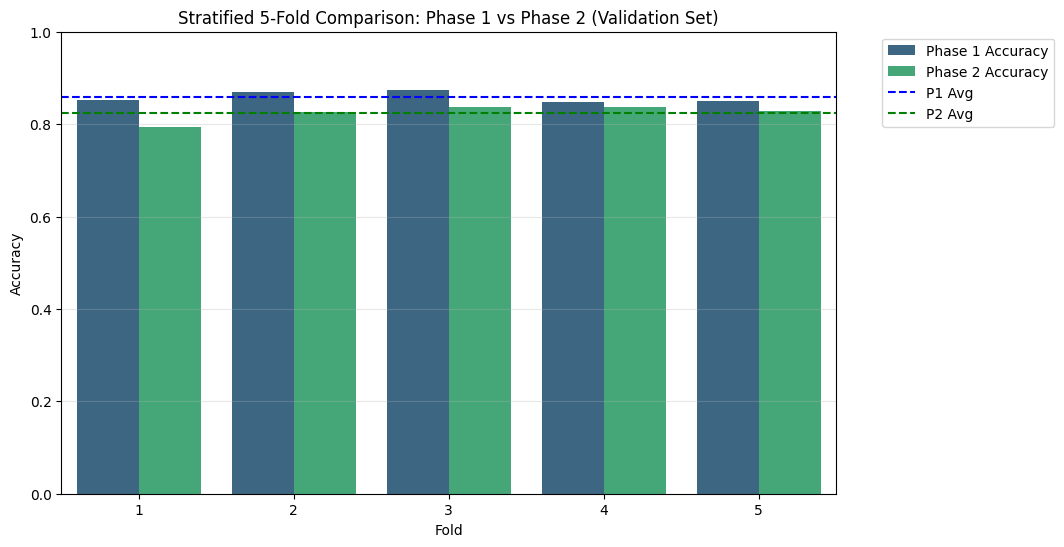

Average Phase 1 Accuracy: 85.87%
Average Phase 2 Accuracy: 82.46%
Robustness Gap: 3.40%


In [7]:
print("\nSummary Statistics:")
display(results_df.describe())

# Visualization
plt.figure(figsize=(10, 6))
df_melted = results_df.melt(id_vars='Fold', var_name='Phase', value_name='Accuracy')
sns.barplot(data=df_melted, x='Fold', y='Accuracy', hue='Phase', palette='viridis')
plt.title(f'Stratified {NUM_FOLDS}-Fold Comparison: Phase 1 vs Phase 2 (Validation Set)')
plt.ylim(0, 1.0)
plt.axhline(results_df['Phase 1 Accuracy'].mean(), color='blue', linestyle='--', label='P1 Avg')
plt.axhline(results_df['Phase 2 Accuracy'].mean(), color='green', linestyle='--', label='P2 Avg')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average Phase 1 Accuracy: {results_df['Phase 1 Accuracy'].mean():.2%}")
print(f"Average Phase 2 Accuracy: {results_df['Phase 2 Accuracy'].mean():.2%}")
print(f"Robustness Gap: {(results_df['Phase 1 Accuracy'].mean() - results_df['Phase 2 Accuracy'].mean()):.2%}")